In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# --- Notebook 2: Reconstruct Data from Weights ---
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
# 1. Define the exact same architecture
class FourLayerNet(nn.Module):
    def __init__(self):
        super(FourLayerNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

In [4]:
# 2. Load the victim's weights
model = FourLayerNet()
model.load_state_dict(torch.load('/content/drive/MyDrive/fedavg_client_weights.pth'))
model.eval() # Set to evaluation mode

# Freeze the model weights (we don't want to change the model, only the input)
for param in model.parameters():
    param.requires_grad = False

In [5]:
# 3. Choose a target class to reconstruct (e.g., the digit "3")
target_class = 3

In [6]:
# 4. Initialize random noise as our starting "image"
# requires_grad=True is crucial here: we are going to optimize the pixels!
dummy_image = torch.randn(1, 1, 28, 28, requires_grad=True)


In [7]:
# 5. Optimizer setup (optimizing the image, NOT the model parameters)
optimizer = torch.optim.Adam([dummy_image], lr=0.1)

In [8]:
# 6. Optimization Loop (The Inversion Attack)
print(f"Reconstructing features for class {target_class}...")
for iteration in range(2000):
    optimizer.zero_grad()

    # Pass the dummy image through the network
    output = model(dummy_image)

    # We want to MAXIMIZE the network's confidence in our target class.
    # Minimizing the negative output is the same as maximizing the output.
    loss = -output[0, target_class]

    # Calculate gradients with respect to the dummy image pixels
    loss.backward()

    # Update the dummy image pixels
    optimizer.step()

Reconstructing features for class 3...


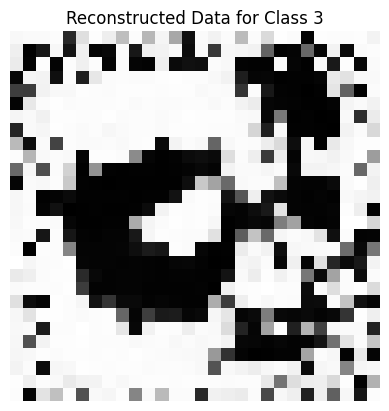

In [9]:
# 7. Visualize the result
reconstructed_image = dummy_image.detach().numpy().reshape(28, 28)

plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Reconstructed Data for Class {target_class}")
plt.axis('off')
plt.show()

In [12]:
import torch.nn.functional as F

print("Testing the model's confidence on the reconstructed image...\n")

# 1. Prepare the image
# We convert our singular saved numpy array back into a PyTorch tensor
# and reshape it to (batch_size, channels, height, width)
recon_tensor = torch.tensor(reconstructed_image).view(1, 1, 28, 28)

# 2. Feed it to the model (Inference)
with torch.no_grad():
    raw_output = model(recon_tensor)

# 3. Convert raw scores (logits) to percentages (probabilities)
probabilities = F.softmax(raw_output, dim=1)

# 4. Find the highest percentage
predicted_class = torch.argmax(probabilities).item()
confidence = probabilities[0, predicted_class].item() * 100

print(f"Original Target: {target_class} | Model Predicts: {predicted_class} | Confidence: {confidence:.2f}%")

Testing the model's confidence on the reconstructed image...

Original Target: 3 | Model Predicts: 3 | Confidence: 100.00%
